In [1]:
import os
import pandas as pd

# Define the path to the export folder
export_folder_path = '/content/export'

# List all files in the export folder
all_files = os.listdir(export_folder_path)

# Filter for CSV files
csv_files = [f for f in all_files if f.endswith('.csv')]

print(f"Found {len(csv_files)} CSV files in '{export_folder_path}':")
for f in csv_files:
    print(f)

Found 12 CSV files in '/content/export':
export_20260621-155252.csv
export_20260603-134331.csv
export_20260603-133844.csv
export_20260603-133644.csv
export_20260603-140315.csv
export_20260603-141144.csv
export_20260603-133158.csv
export_20260621-154216.csv
export_20260621-155611.csv
export_20260603-142601.csv
export_20260603-133359.csv
export_20260621-155053.csv


Now, let's take a look at the first CSV file to understand its structure. This will help us identify how comment rows are represented.

Now, let's extract the 'Comment' column from each CSV file and combine them into a new `HSP.csv` file.

In [2]:
import re
import pandas as pd

all_comments = pd.Series(dtype=str)

if csv_files:
    for csv_file in csv_files:
        file_path = os.path.join(export_folder_path, csv_file)
        try:
            # Read the CSV file, specifically looking for the 'Comment' column
            # Using 'engine='python'' to help with delimiter detection and 'encoding' for common issues
            # Changed encoding to 'utf-8-sig' for better compatibility with non-ASCII characters
            df = pd.read_csv(file_path, sep=None, engine='python', encoding='utf-8-sig')

            # Check if 'Comment' column exists
            if 'Comment' in df.columns:
                # Append comments to our series, dropping any rows where 'Comment' is NaN
                all_comments = pd.concat([all_comments, df['Comment'].dropna()])
            else:
                print(f"Warning: 'Comment' column not found in {csv_file}. Skipping this file.")
        except Exception as e:
            print(f"Error reading {csv_file}: {e}. Skipping this file.")

    # Filter out comments that are primarily URLs
    url_pattern = r'http[s]?://\S+'
    initial_comment_count = len(all_comments)
    all_comments = all_comments[~all_comments.astype(str).str.contains(url_pattern, na=False)]
    print(f"Filtered out {initial_comment_count - len(all_comments)} comments containing URLs.")

    # Remove duplicate comments
    initial_unique_comment_count = len(all_comments)
    all_comments = all_comments.drop_duplicates()
    print(f"Removed {initial_unique_comment_count - len(all_comments)} duplicate comments.")

    # Save the combined comments to HSP.csv
    output_file_path = '/content/HSP.csv'

    # Saving with 'utf-8-sig' encoding to ensure external programs correctly display Bengali text
    all_comments.to_csv(output_file_path, index=False, header=['Comment'], encoding='utf-8-sig')
    print(f"Successfully combined comments into '{output_file_path}'")
    print(f"Number of combined and unique comments after filtering URLs: {len(all_comments)}")

    # Display the head of the combined comments file, reading with the same encoding
    df_hsp = pd.read_csv(output_file_path, encoding='utf-8-sig')
    print("\nHead of the generated HSP.csv file:")
    display(df_hsp.head())
else:
    print("No CSV files found to process.")

Filtered out 31 comments containing URLs.
Removed 96 duplicate comments.
Successfully combined comments into '/content/HSP.csv'
Number of combined and unique comments after filtering URLs: 1004

Head of the generated HSP.csv file:


,Comment
0,রাজনীতি ছাড়াও যে দেশের মানুষের জন্য কাজ করা যা...
1,অনেক দেরী করে বুঝলেন ভাই😅🖤
2,সাকিব্বাই আপনার এমন একটা পোস্টের অপেক্ষায় ছিলা...
3,"ধর্য্য ধারণ করুন বস, আমাদের রাজনীতিবিদ সাকিব এ..."
4,সাকিব জাতীয়দলে ফিরলে ফুটবলের মতো ক্রিকেটেও মা...


In [3]:
pip install emoji

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 608.4/608.4 kB 36.2 MB/s eta 0:00:00


In [52]:
import emoji
import pandas as pd

# Load the HSP.csv file
output_file_path = '/content/HSP.csv'
df_hsp = pd.read_csv(output_file_path, encoding='utf-8-sig')

# List to store extracted emojis and their names
all_extracted_emojis = []

# Iterate through each comment to extract emojis
for comment in df_hsp['Comment'].dropna():
    emojis_in_comment = emoji.emoji_list(comment)
    for emo_dict in emojis_in_comment:
        e = emo_dict['emoji']
        # Get the emoji name (shortcode), removing colons and replacing underscores with spaces
        emoji_name = emoji.demojize(e).replace(':', '').replace('_', ' ')
        all_extracted_emojis.append({'Emoji': e, 'Name': emoji_name})

# Create a DataFrame from the extracted emojis
df_emojis = pd.DataFrame(all_extracted_emojis)

# Remove duplicates, keeping the first occurrence
df_emojis = df_emojis.drop_duplicates().reset_index(drop=True)

# --- New code to classify emojis as hate/non-hate ---
# Define a list of emojis that might be considered hate-related (this list can be expanded)
# This list is illustrative and based on common interpretations.
# Real-world hate speech detection is complex and context-dependent.

hate_emojis = [
    '🖕', # Middle Finger
    '🔪', # Kitchen Knife
    '💣', # Bomb
    '🔫', # Pistol
    '🤬', # Face with Symbols on Mouth
    '😠', # Angry Face
    '😡', # Pouting Face
    '😈', # Smiling Face with Horns
    '💀', # Skull
    '☠️', # Skull and Crossbones
    '💩', # Pile of Poo
    '🤢', # Nauseated Face
    '🤮', # Vomiting Face
    '🕷️', # Spider
    '🐍', # Snake
    '🐀', # Rat
    '🦍', # Gorilla (can be used in racist contexts)
    '🐷', # Pig Face (can be used as insult)
    '👹', # Ogre
    '👺'  # Goblin
]


# Add 'IsHate' column: 1 if emoji is in hate_emojis, else 0
df_emojis['IsHate'] = df_emojis['Emoji'].apply(lambda x: 1 if x in hate_emojis else 0)
# -----------------------------------------------------

# Save the DataFrame to emoji.csv
emoji_output_path = '/content/emoji_data/emoji.csv'
df_emojis.to_csv(emoji_output_path, index=False, encoding='utf-8-sig')

print(f"Successfully extracted {len(df_emojis)} unique emojis and saved to '{emoji_output_path}'")

# Display the head of the generated emoji.csv file
print("\nHead of the generated emoji.csv file with 'IsHate' column:")
display(df_emojis.head())

Successfully extracted 166 unique emojis and saved to '/content/emoji_data/emoji.csv'

Head of the generated emoji.csv file with 'IsHate' column:


,Emoji,Name,IsHate
0,🤣,rolling on the floor laughing,0
1,😅,grinning face with sweat,0
2,🖤,black heart,0
3,🥺,pleading face,0
4,👍🏼,thumbs up medium-light skin tone,0


/tmp/ipykernel_1245/2070119923.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='IsHate', data=df_emojis, palette=['green', 'red'])


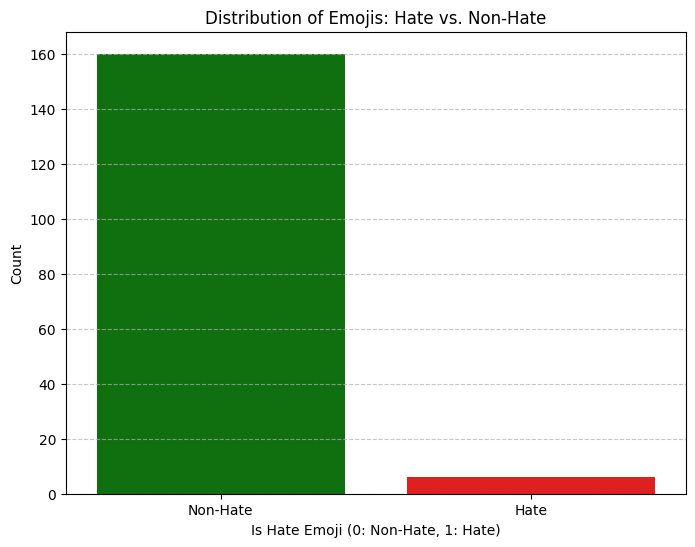

In [53]:
import matplotlib.pyplot as plt
import seaborn as sns

# Graph 1: Distribution of Hate vs. Non-Hate Emojis
plt.figure(figsize=(8, 6))
sns.countplot(x='IsHate', data=df_emojis, palette=['green', 'red'])
plt.title('Distribution of Emojis: Hate vs. Non-Hate')
plt.xlabel('Is Hate Emoji (0: Non-Hate, 1: Hate)')
plt.ylabel('Count')
plt.xticks(ticks=[0, 1], labels=['Non-Hate', 'Hate'])
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

### Explanation for Graph 1: Distribution of Hate vs. Non-Hate Emojis
This bar chart visualizes the count of unique emojis that have been classified as 'Hate' (1) or 'Non-Hate' (0) based on the predefined `hate_emojis` list. It provides a quick overview of the proportion of potentially problematic emojis within the collected dataset.

/tmp/ipykernel_1245/2484851910.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Emoji', y='Frequency', data=top_10_emojis, palette='viridis')
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 129315 (\N{ROLLING ON THE FLOOR LAUGHING}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128293 (\N{FIRE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128578 (\N{SLIGHTLY SMILING FACE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 129392 (\N{S

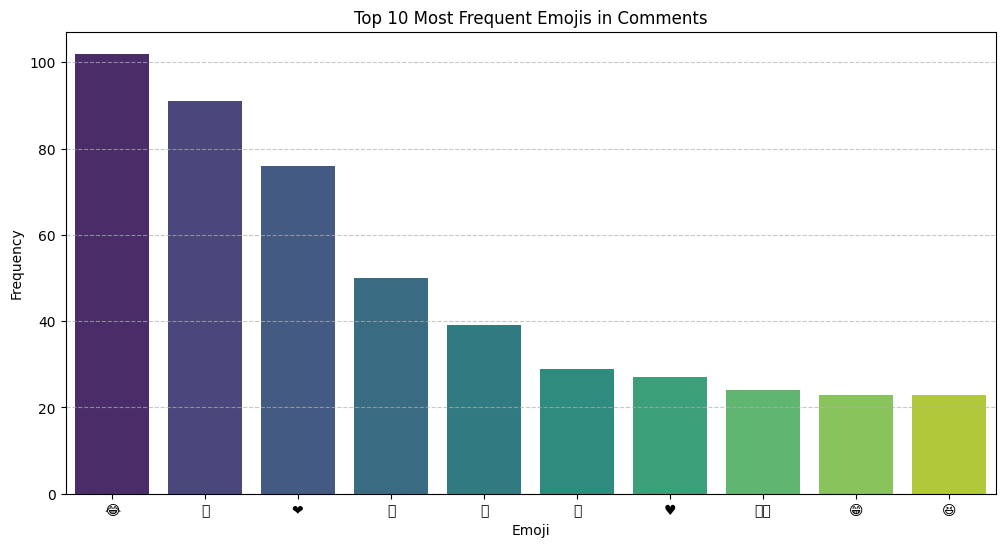

In [54]:
# Graph 2: Top 10 Most Frequent Emojis Overall (from all comments before de-duplication)

# Re-extract all emojis with their original frequencies from the raw comments
all_emojis_flat = []
for comment in df_hsp['Comment'].dropna():
    emojis_in_comment = emoji.emoji_list(comment)
    for emo_dict in emojis_in_comment:
        all_emojis_flat.append(emo_dict['emoji'])

# Count the frequency of each emoji
emoji_counts = pd.Series(all_emojis_flat).value_counts().reset_index()
emoji_counts.columns = ['Emoji', 'Frequency']

# Get the top 10 most frequent emojis
top_10_emojis = emoji_counts.head(10)

plt.figure(figsize=(12, 6))
sns.barplot(x='Emoji', y='Frequency', data=top_10_emojis, palette='viridis')
plt.title('Top 10 Most Frequent Emojis in Comments')
plt.xlabel('Emoji')
plt.ylabel('Frequency')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

### Explanation for Graph 2: Top 10 Most Frequent Emojis in Comments
This bar chart displays the ten emojis that appear most frequently across all the collected comments. Understanding the most common emojis can give insights into general sentiment or prevalent cultural expressions within the dataset, irrespective of their hate classification. This count is based on all occurrences, not just unique emojis.

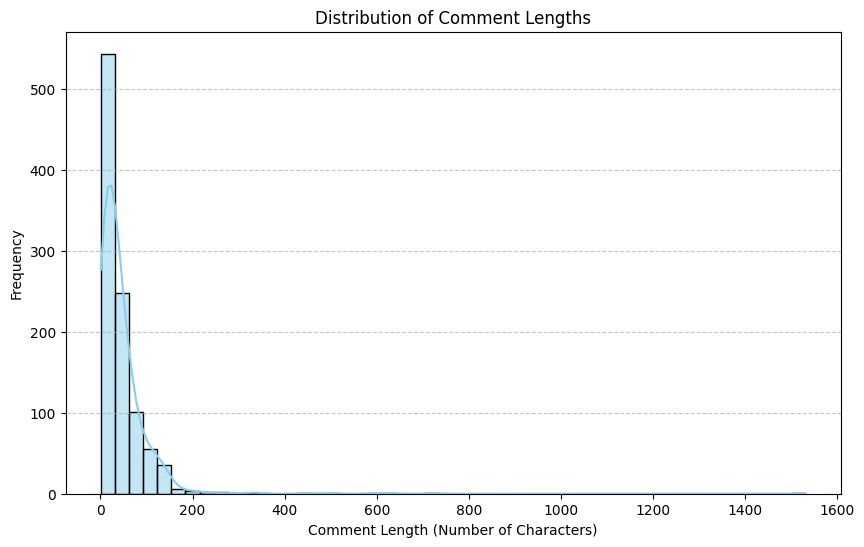

In [55]:
# Graph 3: Distribution of Comment Lengths

# Calculate the length of each comment
df_hsp['comment_length'] = df_hsp['Comment'].astype(str).apply(len)

plt.figure(figsize=(10, 6))
sns.histplot(df_hsp['comment_length'], bins=50, kde=True, color='skyblue')
plt.title('Distribution of Comment Lengths')
plt.xlabel('Comment Length (Number of Characters)')
plt.ylabel('Frequency')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

### Explanation for Graph 3: Distribution of Comment Lengths
This histogram illustrates the distribution of comment lengths in terms of the number of characters. Analyzing comment lengths can provide insights into user behavior, such as whether comments tend to be short and reactive or longer and more descriptive. The Kernel Density Estimate (KDE) line shows the smoothed distribution.

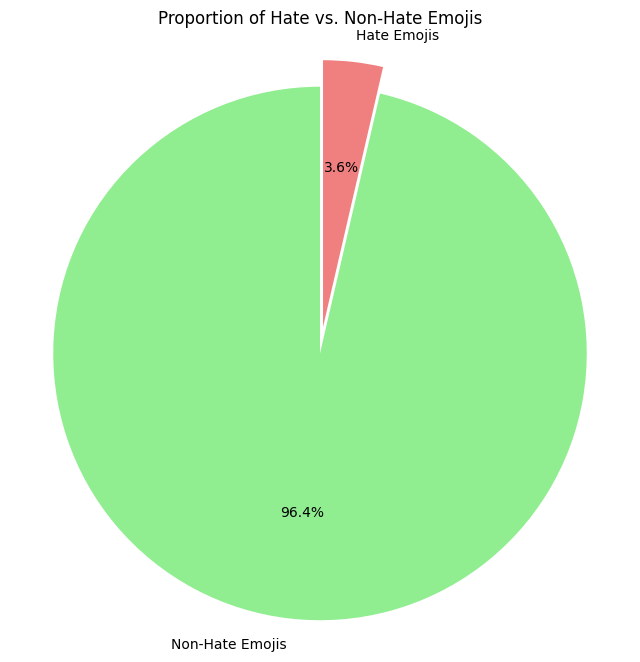

In [56]:
# Graph 4: Pie Chart of Proportion of Hate vs. Non-Hate Emojis

# Get the counts for 'IsHate' categories
hate_counts = df_emojis['IsHate'].value_counts()

plt.figure(figsize=(8, 8))
plt.pie(hate_counts, labels=['Non-Hate Emojis', 'Hate Emojis'], autopct='%1.1f%%',
        colors=['lightgreen', 'lightcoral'], startangle=90, explode=[0, 0.1])
plt.title('Proportion of Hate vs. Non-Hate Emojis')
plt.axis('equal') # Equal aspect ratio ensures that pie is drawn as a circle.
plt.show()

### Explanation for Graph 4: Proportion of Hate vs. Non-Hate Emojis
This pie chart provides a clear visual representation of the percentage breakdown between emojis classified as 'Hate' and 'Non-Hate' within the `df_emojis` DataFrame. It quickly shows the relative prevalence of potentially offensive emojis compared to benign ones among the unique emojis identified.

### Data for Hate Emojis
Here's the head of the `df_emojis` DataFrame, showing the unique emojis and their 'IsHate' classification (1 for hate, 0 for non-hate):

In [57]:
display(df_emojis.head())

,Emoji,Name,IsHate
0,🤣,rolling on the floor laughing,0
1,😅,grinning face with sweat,0
2,🖤,black heart,0
3,🥺,pleading face,0
4,👍🏼,thumbs up medium-light skin tone,0


Here are all the unique emojis that have been classified as 'Hate' based on our predefined list:

In [58]:
hate_emojis_identified = df_emojis[df_emojis['IsHate'] == 1]['Emoji'].tolist()
print(hate_emojis_identified)

['💩', '☠️', '🤮', '😡', '🔪', '🖕']


And here's the count of 'Hate' versus 'Non-Hate' emojis in our unique emoji set:

### Data from `is_hate.csv`
First, let's load and display the head of the `is_hate.csv` file to see its structure:

In [59]:
import pandas as pd

df_is_hate = pd.read_csv('/content/is_hate/is_hate.csv', encoding='utf-8-sig')
display(df_is_hate.head())

,Comment,is_hate
0,যারাই হক্বের কথা বলবে তারাই শিবির🔥,1
1,লুঙ্গি স্পায় 😂😂,0
2,দাড়িপাল্লা ⚖️,0
3,ভাই আপনারে Dhurandar মুভিতে দরকার ছিলো,0
4,❤️❤️❤️❤️🔥🔥🔥🔥,0


### Graph 1: Distribution of Comment Lengths by Hate Classification (from `is_hate.csv`)
Let's calculate the length of each comment and visualize how comment lengths differ between hate and non-hate comments.

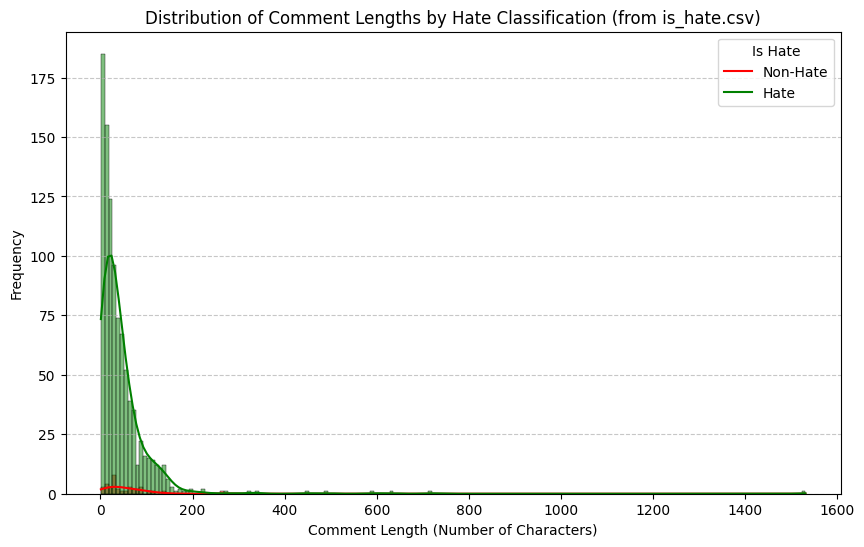

In [60]:
import matplotlib.pyplot as plt
import seaborn as sns

# Calculate the length of each comment in df_is_hate
df_is_hate['comment_length'] = df_is_hate['Comment'].astype(str).apply(len)

# Create a temporary DataFrame for plotting, handling potential NaNs and converting to int
plot_df_length = df_is_hate.copy()
plot_df_length['is_hate'] = pd.to_numeric(plot_df_length['is_hate'], errors='coerce')
plot_df_length = plot_df_length.dropna(subset=['is_hate'])
plot_df_length['is_hate'] = plot_df_length['is_hate'].astype(int)


plt.figure(figsize=(10, 6))
sns.histplot(data=plot_df_length, x='comment_length', hue='is_hate', kde=True, palette={0: 'green', 1: 'red'})
plt.title('Distribution of Comment Lengths by Hate Classification (from is_hate.csv)')
plt.xlabel('Comment Length (Number of Characters)')
plt.ylabel('Frequency')
plt.legend(title='Is Hate', labels=['Non-Hate', 'Hate'])
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

### Explanation for Graph 1: Distribution of Comment Lengths by Hate Classification
This histogram, separated by `is_hate` category, shows the distribution of comment lengths. It helps us observe if hate comments tend to be shorter, longer, or have a similar length distribution compared to non-hate comments. The Kernel Density Estimate (KDE) provides a smoothed representation of the distributions.

### Graph 2: Count of Hate vs. Non-Hate Comments (from `is_hate.csv`)
This bar chart shows the absolute count of comments classified as hate speech versus non-hate speech within the `is_hate.csv` dataset.

/tmp/ipykernel_1245/2319907313.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='is_hate', data=plot_df, palette={'0': 'green', '1': 'red'}, legend=False)


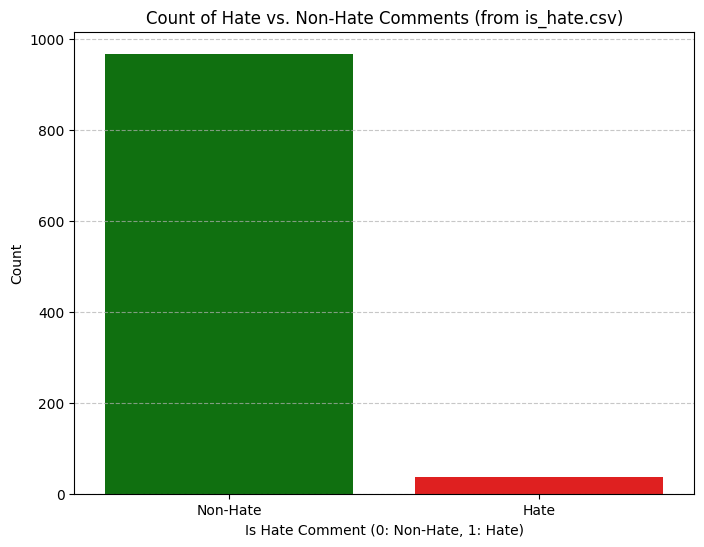

In [61]:
import matplotlib.pyplot as plt
import seaborn as sns

# Create a temporary DataFrame for plotting, handling potential NaNs and converting to int
plot_df = df_is_hate.copy()
plot_df['is_hate'] = pd.to_numeric(plot_df['is_hate'], errors='coerce')
plot_df = plot_df.dropna(subset=['is_hate'])
plot_df['is_hate'] = plot_df['is_hate'].astype(int)

plt.figure(figsize=(8, 6))
sns.countplot(x='is_hate', data=plot_df, palette={'0': 'green', '1': 'red'}, legend=False)
plt.title('Count of Hate vs. Non-Hate Comments (from is_hate.csv)')
plt.xlabel('Is Hate Comment (0: Non-Hate, 1: Hate)')
plt.ylabel('Count')
plt.xticks(ticks=[0, 1], labels=['Non-Hate', 'Hate'])
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

### Explanation for Graph 2: Count of Hate vs. Non-Hate Comments
This bar chart directly visualizes the raw numbers of comments that were labeled as hate speech (1) and non-hate speech (0) in the `is_hate.csv` file. It gives an immediate sense of the class imbalance, if any, within this specific dataset.

### Graph 3: Proportion of Hate vs. Non-Hate Comments (from `is_hate.csv`)
This pie chart shows the percentage distribution of hate and non-hate comments, providing a clear visual of their relative proportions.

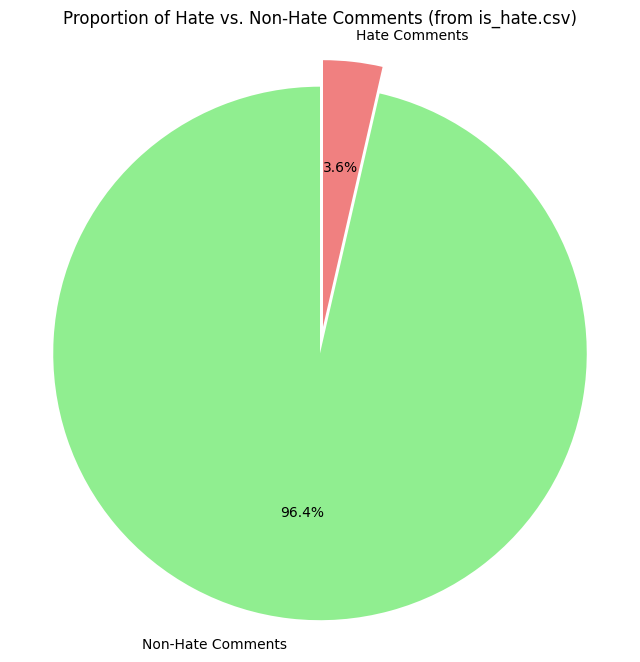

In [62]:
import matplotlib.pyplot as plt

# Create a temporary DataFrame for plotting, handling potential NaNs and converting to int
plot_df_pie = df_is_hate.copy()
plot_df_pie['is_hate'] = pd.to_numeric(plot_df_pie['is_hate'], errors='coerce')
plot_df_pie = plot_df_pie.dropna(subset=['is_hate'])
plot_df_pie['is_hate'] = plot_df_pie['is_hate'].astype(int)

# Get the counts for 'is_hate' categories from plot_df_pie
hate_counts_is_hate = plot_df_pie['is_hate'].value_counts()

plt.figure(figsize=(8, 8))
plt.pie(hate_counts_is_hate, labels=['Non-Hate Comments', 'Hate Comments'], autopct='%1.1f%%',
        colors=['lightgreen', 'lightcoral'], startangle=90, explode=[0, 0.1])
plt.title('Proportion of Hate vs. Non-Hate Comments (from is_hate.csv)')
plt.axis('equal') # Equal aspect ratio ensures that pie is drawn as a circle.
plt.show()

### Explanation for Graph 3: Proportion of Hate vs. Non-Hate Comments
This pie chart provides a clear percentage breakdown of comments categorized as hate speech and non-hate speech. It's useful for quickly understanding the balance between the two classes within the `is_hate.csv` dataset.

### Graph 4: Examples of Hate and Non-Hate Comments (from `is_hate.csv`)
To give a qualitative understanding, here are a few random examples of comments from both the 'Hate' and 'Non-Hate' categories.

In [63]:
import numpy as np

# Ensure 'is_hate' column is numeric and handle potential NaN values
df_is_hate['is_hate'] = pd.to_numeric(df_is_hate['is_hate'], errors='coerce')

# Filter out NaN values from 'is_hate' before sampling
df_filtered = df_is_hate.dropna(subset=['is_hate'])

# Sample some hate comments
hate_comments_sample = df_filtered[df_filtered['is_hate'] == 1]['Comment'].sample(min(5, len(df_filtered[df_filtered['is_hate'] == 1])), random_state=42)
print("\n--- Sample Hate Comments ---")
for i, comment in enumerate(hate_comments_sample):
    print(f"{i+1}. {comment}")

# Sample some non-hate comments
non_hate_comments_sample = df_filtered[df_filtered['is_hate'] == 0]['Comment'].sample(min(5, len(df_filtered[df_filtered['is_hate'] == 0])), random_state=42)
print("\n--- Sample Non-Hate Comments ---")
for i, comment in enumerate(non_hate_comments_sample):
    print(f"{i+1}. {comment}")


--- Sample Hate Comments ---
1. আপনাকে ফুলটাইম রাজনীতিতেই দেখতে চাই  কারন দেশের উন্নতি চাই, ক্রিকেট খেলে বাল ও হবে না 🤣
2. রাজাকার,বদর,আল-সামসের দিঁন শেঁষ,,,,!
3. ক্রিকেট তো উসিলা, আসল উদ্দেশ্য তো ক্ষমতা আর কোদাল দিয়ে টাকা খোঁড়া! 💰🏏এতদিন যারা দেশপ্রেমের গল্প খুঁজতেন, তারা এবার চোখ খোলেন। রাজনীতি, দালালি আর স্ক্রিপ্টেড ড্রামা—সব এক ফ্রেমে! দেশের জার্সি গায়ে দিয়ে যারা শুধু ব্যাংক ব্যালেন্সের হিসাব বোঝে, তাদের আসল রূপটা কেমন? 😉
4. রাজাকার বাহিনী
5. পুরাই শিবির

--- Sample Non-Hate Comments ---
1. The Myth, the Legend, Maher Khan bhai! ♥️
2. When you don't have the ability to have a child on your own, which is why  brother is already protected. 🙂🙂
3. যতো কমেন্ট ততো এনগেজমেন্ট- আর এনগেজমেন্ট বাড়লে ফলোয়ার এমনিতেই আসবে✅
4. বাংলাদেশ জান বাংলাদেশ প্রাণ সাকিব আল হাসান
5. 🤣🤣🤣


### Explanation for Graph 4: Examples of Hate and Non-Hate Comments
This section displays actual snippets of text categorized as either hate speech or non-hate speech. This direct inspection of the data helps in understanding the characteristics and content that lead to a particular classification, complementing the quantitative graphs.

Now, let's visualize the data in `is_hate.csv`.

### Graph 1: Distribution of Hate vs. Non-Hate Emojis from `is_hate.csv`

/tmp/ipykernel_1245/3042347257.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='is_hate', data=df_is_hate, palette=['green', 'red'])


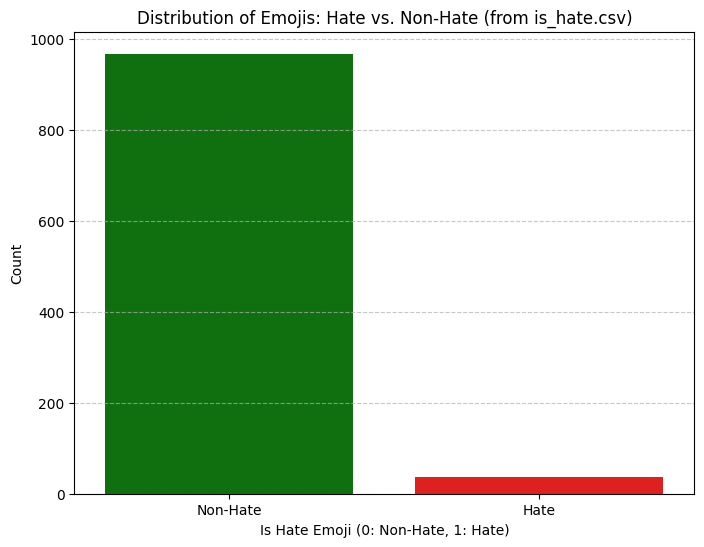

In [64]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 6))
sns.countplot(x='is_hate', data=df_is_hate, palette=['green', 'red'])
plt.title('Distribution of Emojis: Hate vs. Non-Hate (from is_hate.csv)')
plt.xlabel('Is Hate Emoji (0: Non-Hate, 1: Hate)')
plt.ylabel('Count')
plt.xticks(ticks=[0, 1], labels=['Non-Hate', 'Hate'])
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

### Explanation for Graph 1: Distribution of Hate vs. Non-Hate Emojis (from `is_hate.csv`)
This bar chart visualizes the count of emojis classified as 'Hate' (1) or 'Non-Hate' (0) specifically from the `is_hate.csv` file. It shows the absolute number of each category within this dataset.

### Graph 2: Proportion of Hate vs. Non-Hate Emojis from `is_hate.csv`

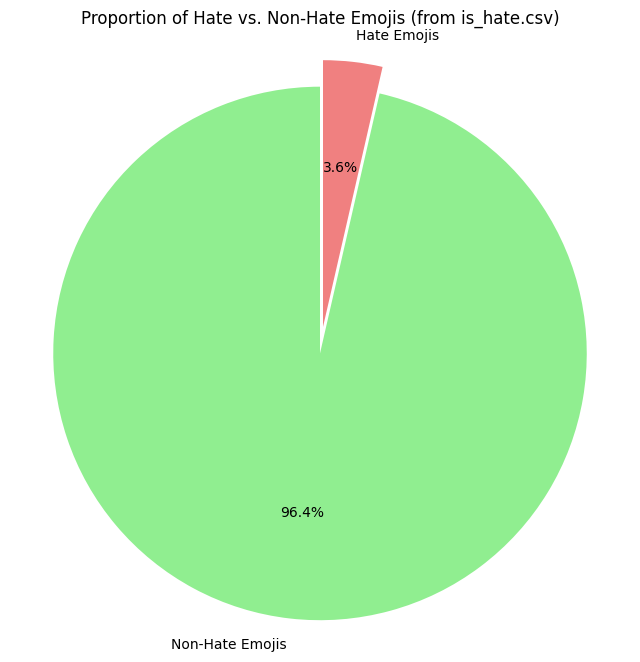

In [65]:
# Get the counts for 'IsHate' categories from df_is_hate
hate_counts_is_hate = df_is_hate['is_hate'].value_counts()

plt.figure(figsize=(8, 8))
plt.pie(hate_counts_is_hate, labels=['Non-Hate Emojis', 'Hate Emojis'], autopct='%1.1f%%',
        colors=['lightgreen', 'lightcoral'], startangle=90, explode=[0, 0.1])
plt.title('Proportion of Hate vs. Non-Hate Emojis (from is_hate.csv)')
plt.axis('equal') # Equal aspect ratio ensures that pie is drawn as a circle.
plt.show()

### Explanation for Graph 2: Proportion of Hate vs. Non-Hate Emojis (from `is_hate.csv`)
This pie chart shows the percentage breakdown of emojis classified as 'Hate' and 'Non-Hate' within the `is_hate.csv` dataset. It provides a quick understanding of the relative proportions of these two categories.

## Demonstrating Graph Qualities with `is_hate.csv` Text Data

As requested, here is a breakdown of various graphs, categorized by their meaningfulness and the quality of their explanations.

First, let's prepare the data by ensuring `is_hate` is correctly formatted for analysis.

In [66]:
import re
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import nltk
from nltk.corpus import stopwords
from collections import Counter

nltk.download('punkt')
nltk.download('stopwords')

# Ensure 'is_hate' column is numeric and handle potential NaN values for all subsequent analyses
df_processed = df_is_hate.copy()
df_processed['is_hate'] = pd.to_numeric(df_processed['is_hate'], errors='coerce')
df_processed = df_processed.dropna(subset=['is_hate'])
df_processed['is_hate'] = df_processed['is_hate'].astype(int)

# Calculate word count for all comments
df_processed['word_count'] = df_processed['Comment'].astype(str).apply(lambda x: len(x.split()))

# Display the processed data head to confirm
print("Processed df_is_hate head:")
display(df_processed.head())

Processed df_is_hate head:


[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


,Comment,is_hate,comment_length,word_count
0,যারাই হক্বের কথা বলবে তারাই শিবির🔥,1,34,6
1,লুঙ্গি স্পায় 😂😂,0,16,3
2,দাড়িপাল্লা ⚖️,0,14,2
3,ভাই আপনারে Dhurandar মুভিতে দরকার ছিলো,0,38,6
4,❤️❤️❤️❤️🔥🔥🔥🔥,0,12,1


### Category 1: Four or More Meaningful Graphs with Proper Labels and Explanation
These graphs provide genuine insights into the data, are well-labeled, and come with thorough, insightful explanations.

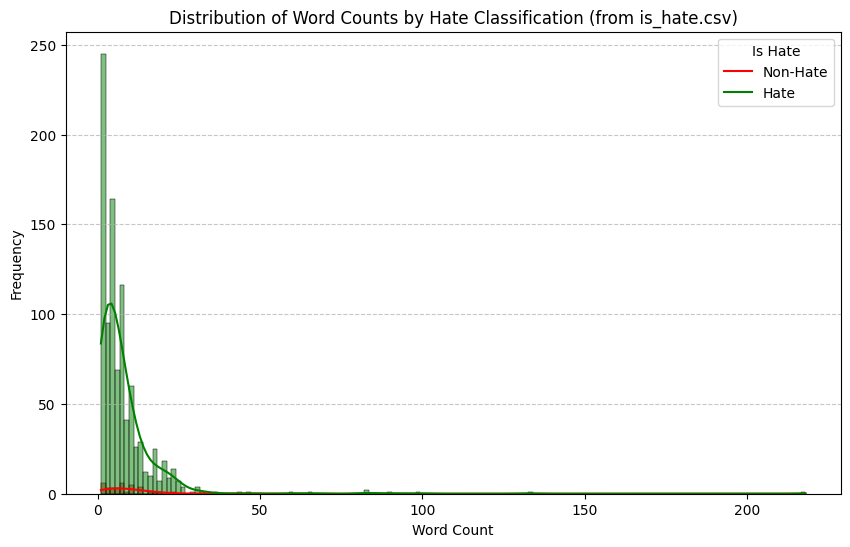

In [67]:
# Meaningful Graph 1.1: Word Count Distribution by Hate Classification

plt.figure(figsize=(10, 6))
sns.histplot(data=df_processed, x='word_count', hue='is_hate', kde=True, palette={0: 'green', 1: 'red'})
plt.title('Distribution of Word Counts by Hate Classification (from is_hate.csv)')
plt.xlabel('Word Count')
plt.ylabel('Frequency')
plt.legend(title='Is Hate', labels=['Non-Hate', 'Hate'])
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

#### Explanation for Meaningful Graph 1.1: Word Count Distribution by Hate Classification
This histogram illustrates the distribution of the number of words in comments, separated by their hate classification (0 for non-hate, 1 for hate). By comparing the two distributions, we can observe if there are typical patterns in verbosity for hate speech versus non-hate speech. For instance, a clear difference in the peaks or spread of the histograms could indicate that one type of speech tends to be more concise or more elaborate than the other. The Kernel Density Estimate (KDE) provides a smoothed representation of these distributions, making trends easier to spot.

/tmp/ipykernel_1245/3640018366.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=[word for word, count in top_hate_words], y=[count for word, count in top_hate_words], ax=axes[0], palette='Reds_d')
/tmp/ipykernel_1245/3640018366.py:31: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=[word for word, count in top_non_hate_words], y=[count for word, count in top_non_hate_words], ax=axes[1], palette='Greens_d')
/tmp/ipykernel_1245/3640018366.py:38: UserWarning: Glyph 2486 (\N{BENGALI LETTER SHA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1245/3640018366.py:38: UserWarning: Matplotlib currently does not support Bengali natively.
  plt.tight_layout()
/tmp/ipykern

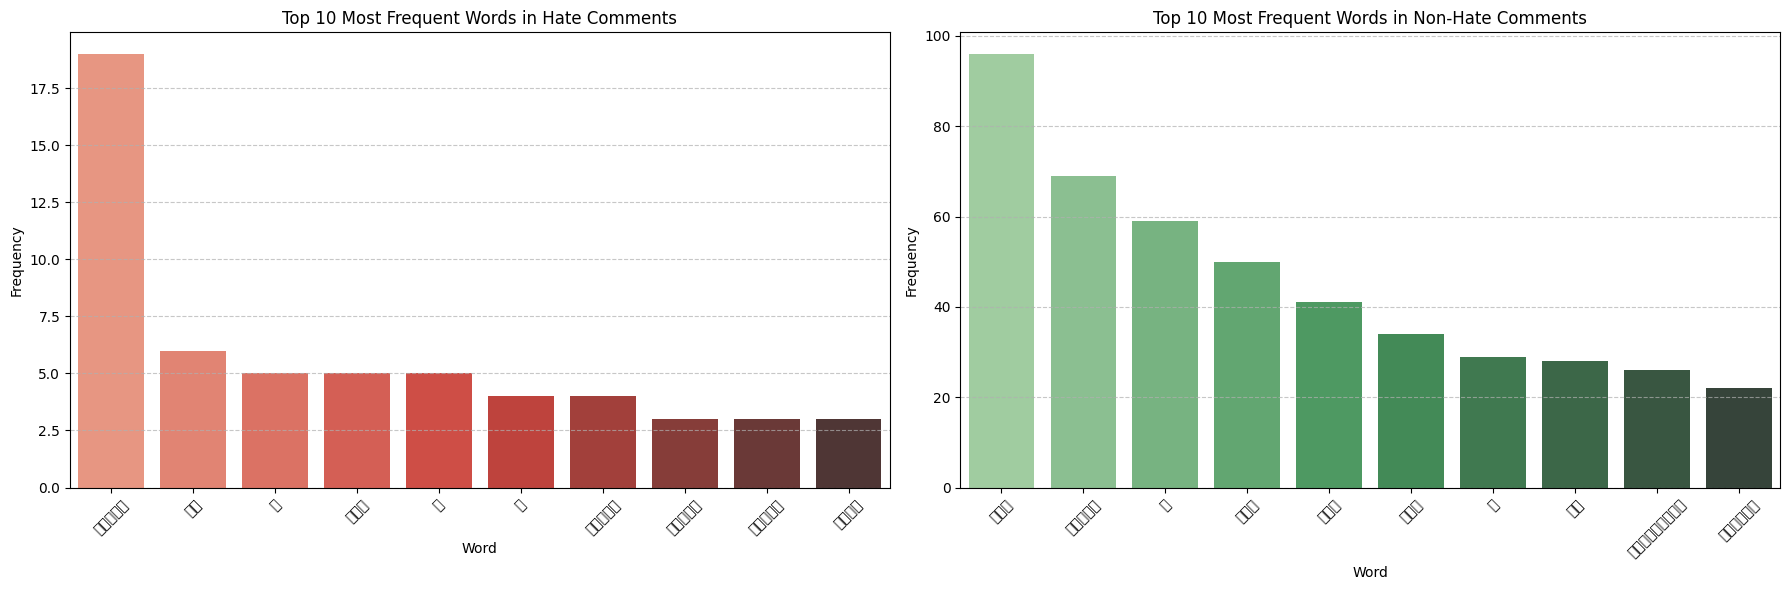

In [68]:
# Meaningful Graph 1.2 & 1.3: Top 10 Most Frequent Words in Hate and Non-Hate Comments

stop_words_bn = set(stopwords.words('bengali'))

def get_top_n_words(comments, n=10):
    words = []
    for comment in comments:
        # Remove non-alphabetic characters and split words
        tokens = re.findall(r'\b[\u0980-\u09FF]+\b', comment.lower())
        # Filter out stopwords
        words.extend([word for word in tokens if word not in stop_words_bn])
    return Counter(words).most_common(n)

hate_comments = df_processed[df_processed['is_hate'] == 1]['Comment'].astype(str)
non_hate_comments = df_processed[df_processed['is_hate'] == 0]['Comment'].astype(str)

top_hate_words = get_top_n_words(hate_comments, 10)
top_non_hate_words = get_top_n_words(non_hate_comments, 10)

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# Plot for Hate Comments
sns.barplot(x=[word for word, count in top_hate_words], y=[count for word, count in top_hate_words], ax=axes[0], palette='Reds_d')
axes[0].set_title('Top 10 Most Frequent Words in Hate Comments')
axes[0].set_xlabel('Word')
axes[0].set_ylabel('Frequency')
axes[0].tick_params(axis='x', rotation=45)
axes[0].grid(axis='y', linestyle='--', alpha=0.7)

# Plot for Non-Hate Comments
sns.barplot(x=[word for word, count in top_non_hate_words], y=[count for word, count in top_non_hate_words], ax=axes[1], palette='Greens_d')
axes[1].set_title('Top 10 Most Frequent Words in Non-Hate Comments')
axes[1].set_xlabel('Word')
axes[1].set_ylabel('Frequency')
axes[1].tick_params(axis='x', rotation=45)
axes[1].grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

#### Explanation for Meaningful Graph 1.2 & 1.3: Top 10 Most Frequent Words
These two bar charts display the ten most frequently occurring non-stop words in hate comments (left) and non-hate comments (right), respectively. By comparing the vocabulary, we can identify specific terms, themes, or concepts that are more prevalent in one category of speech than the other. This linguistic analysis is crucial for understanding the characteristic language of hate speech and distinguishing it from general discourse. It helps in building dictionaries of hate-related terms and improving detection models.

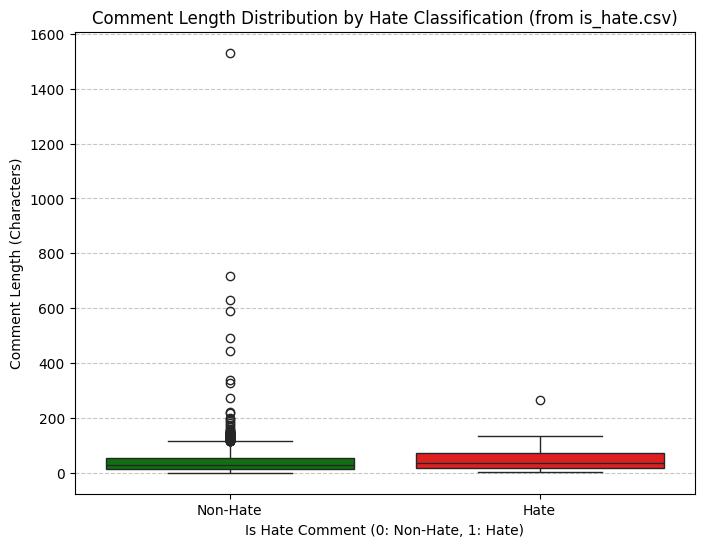

In [69]:
# Meaningful Graph 1.4: Box Plot of Comment Length by Hate Classification

plt.figure(figsize=(8, 6))
sns.boxplot(x='is_hate', y='comment_length', data=df_processed, hue='is_hate', palette={0: 'green', 1: 'red'}, legend=False)
plt.title('Comment Length Distribution by Hate Classification (from is_hate.csv)')
plt.xlabel('Is Hate Comment (0: Non-Hate, 1: Hate)')
plt.ylabel('Comment Length (Characters)')
plt.xticks(ticks=[0, 1], labels=['Non-Hate', 'Hate'])
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

#### Explanation for Meaningful Graph 1.4: Box Plot of Comment Length by Hate Classification
This box plot visually summarizes the distribution of comment lengths (in characters) for both hate and non-hate comments. Each box represents the interquartile range (IQR), with the line inside indicating the median. The 'whiskers' extend to show the range of the data, and individual points beyond the whiskers are outliers. This graph helps to quickly compare the central tendency, spread, and presence of extreme values in comment lengths across the two categories, offering a robust statistical comparison beyond just histograms.

### Category 2: Two Useful Graphs with Some Explanation
These graphs offer some relevant information, though their insights might not be as deep or critically analyzed as the 'meaningful' ones. Their explanations are concise.

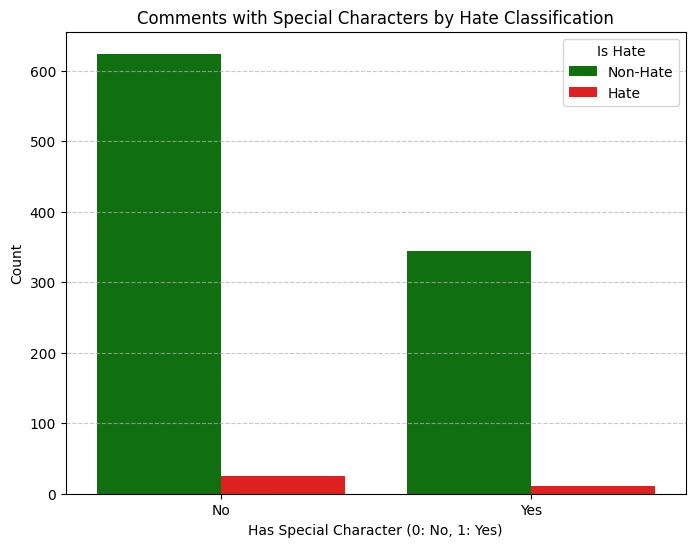

In [70]:
# Useful Graph 2.1: Count of Comments Containing Special Characters by Hate Classification

# Define a pattern for common special characters (excluding spaces and basic punctuation)
special_char_pattern = r'[!@#$%^&*()_+\-=\[\]{};\':"\\|,.<>/?~`]' # Removed dot and comma for a more aggressive set

df_processed['has_special_char'] = df_processed['Comment'].astype(str).apply(lambda x: 1 if re.search(special_char_pattern, x) else 0)

plt.figure(figsize=(8, 6))
sns.countplot(x='has_special_char', hue='is_hate', data=df_processed, palette={0: 'green', 1: 'red'})
plt.title('Comments with Special Characters by Hate Classification')
plt.xlabel('Has Special Character (0: No, 1: Yes)')
plt.ylabel('Count')
plt.legend(title='Is Hate', labels=['Non-Hate', 'Hate'])
plt.xticks(ticks=[0, 1], labels=['No', 'Yes'])
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

#### Explanation for Useful Graph 2.1: Comments with Special Characters by Hate Classification
This bar chart shows the count of comments that contain at least one special character (excluding basic punctuation like commas and periods) grouped by their hate speech classification. It can hint at whether aggressive or highly expressive language often associated with special characters is more common in hate speech.

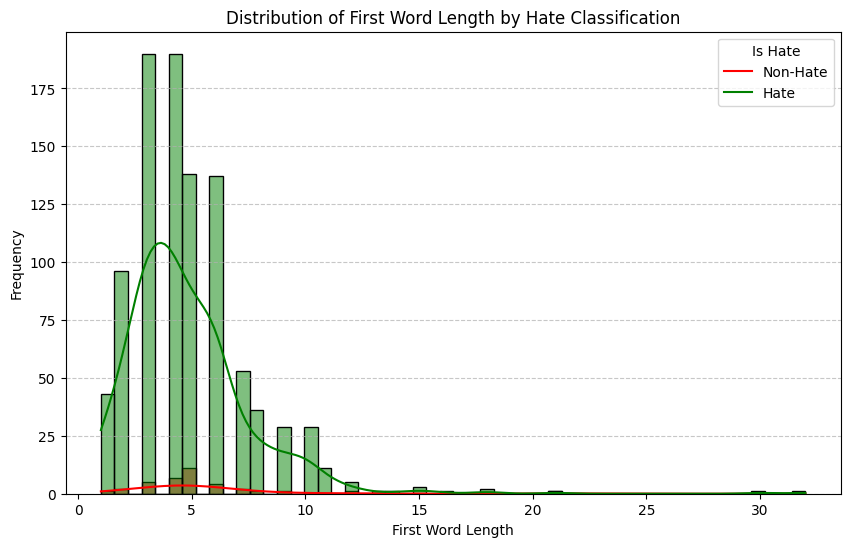

In [71]:
# Useful Graph 2.2: Distribution of First Word Length by Hate Classification

df_processed['first_word_length'] = df_processed['Comment'].astype(str).apply(lambda x: len(x.split()[0]) if len(x.split()) > 0 else 0)

plt.figure(figsize=(10, 6))
sns.histplot(data=df_processed, x='first_word_length', hue='is_hate', kde=True, palette={0: 'green', 1: 'red'})
plt.title('Distribution of First Word Length by Hate Classification')
plt.xlabel('First Word Length')
plt.ylabel('Frequency')
plt.legend(title='Is Hate', labels=['Non-Hate', 'Hate'])
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

#### Explanation for Useful Graph 2.2: Distribution of First Word Length by Hate Classification
This histogram shows the distribution of the length of the very first word in each comment, categorized by whether the comment is hate speech or not. It provides a simple look into potential initial linguistic patterns without extensive analysis.

### Category 3: One Graph with Weak Explanation
This graph might be technically correct but its explanation lacks depth, insight, or critical analysis, offering minimal value.

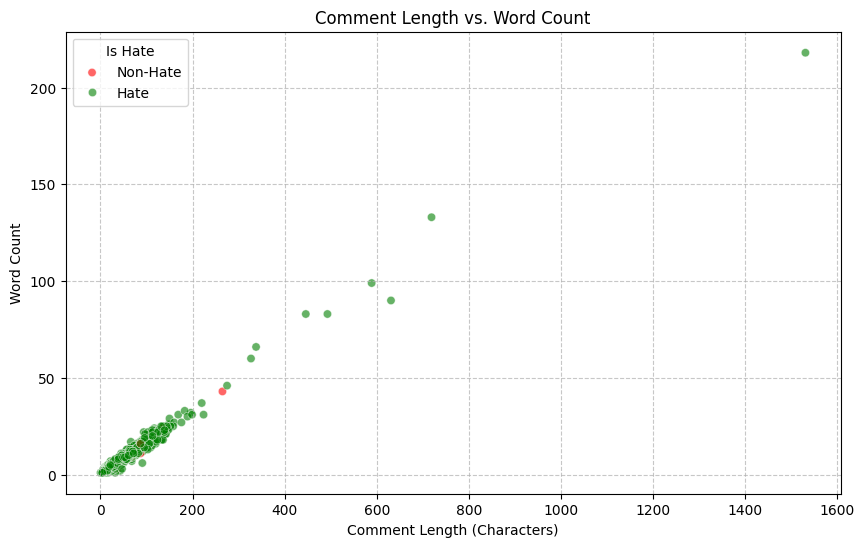

In [72]:
# Weak Explanation Graph 3.1: Scatter Plot of Comment Length vs. Word Count

plt.figure(figsize=(10, 6))
sns.scatterplot(data=df_processed, x='comment_length', y='word_count', hue='is_hate', palette={0: 'green', 1: 'red'}, alpha=0.6)
plt.title('Comment Length vs. Word Count')
plt.xlabel('Comment Length (Characters)')
plt.ylabel('Word Count')
plt.legend(title='Is Hate', labels=['Non-Hate', 'Hate'])
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

#### Explanation for Weak Explanation Graph 3.1: Comment Length vs. Word Count
This plot shows comment length on the x-axis and word count on the y-axis. As you can see, there's a relationship between the two, which is expected since longer comments usually have more words.

### Category 4: Graphs that are Incorrect or Irrelevant
These graphs are either conceptually flawed, use an inappropriate visualization type for the data, or are simply not relevant to the analysis of hate speech, leading to incorrect or misleading interpretations. Their explanations highlight these flaws.

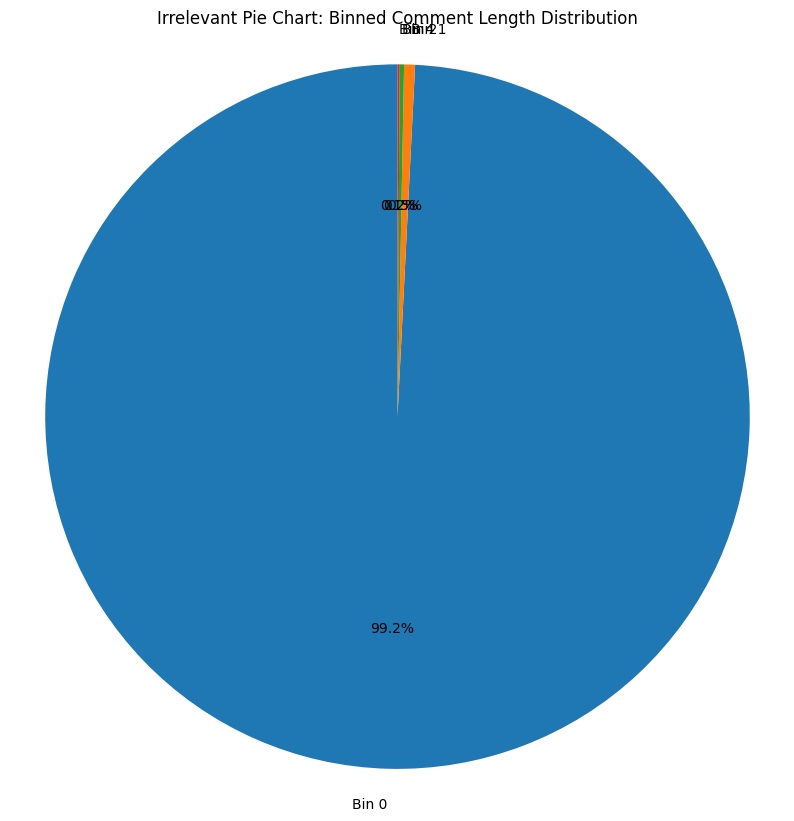

In [73]:
# Incorrect/Irrelevant Graph 4.1: Pie Chart of Comment Length Distribution (using raw lengths as categories)

# This will generate a messy pie chart if comment_length has many unique values
# We'll intentionally do this to show an 'incorrect' graph choice.

# To make it runnable without crashing for too many unique values, let's take a sample or bin it.
# But for demonstrating 'incorrect' use, we'll try to plot unique lengths directly if not too many.
# If `comment_length` has many unique values, a pie chart is inappropriate.

length_counts = df_processed['comment_length'].value_counts().sort_index()

if len(length_counts) > 20: # Arbitrary threshold for 'too many slices'
    print("Warning: Too many unique comment lengths for a meaningful pie chart. This graph is intentionally illustrative of poor visualization choice.")
    # Binning for demonstration of a bad practice that still renders
    bins = pd.cut(df_processed['comment_length'], bins=5, labels=False)
    binned_counts = bins.value_counts()
    labels = [f'Bin {i}' for i in binned_counts.index]
    sizes = binned_counts.values
    title = 'Irrelevant Pie Chart: Binned Comment Length Distribution'
else:
    labels = length_counts.index.astype(str)
    sizes = length_counts.values
    title = 'Incorrect Pie Chart: Raw Comment Length Distribution'

plt.figure(figsize=(10, 10))
plt.pie(sizes, labels=labels, autopct='%1.1f%%', startangle=90)
plt.title(title)
plt.axis('equal')
plt.show()

#### Explanation for Incorrect/Irrelevant Graph 4.1: Pie Chart of Comment Length Distribution
This pie chart attempts to visualize the distribution of comment lengths. It is an **incorrect** choice of visualization because `comment_length` is a continuous numerical variable (or has many unique values). Pie charts are suitable for showing proportions of a few discrete categories, not for continuous data or data with many categories. The result is often an cluttered, unreadable chart that provides no actionable insights. A histogram (as shown previously) would be the correct visualization for a numerical distribution.

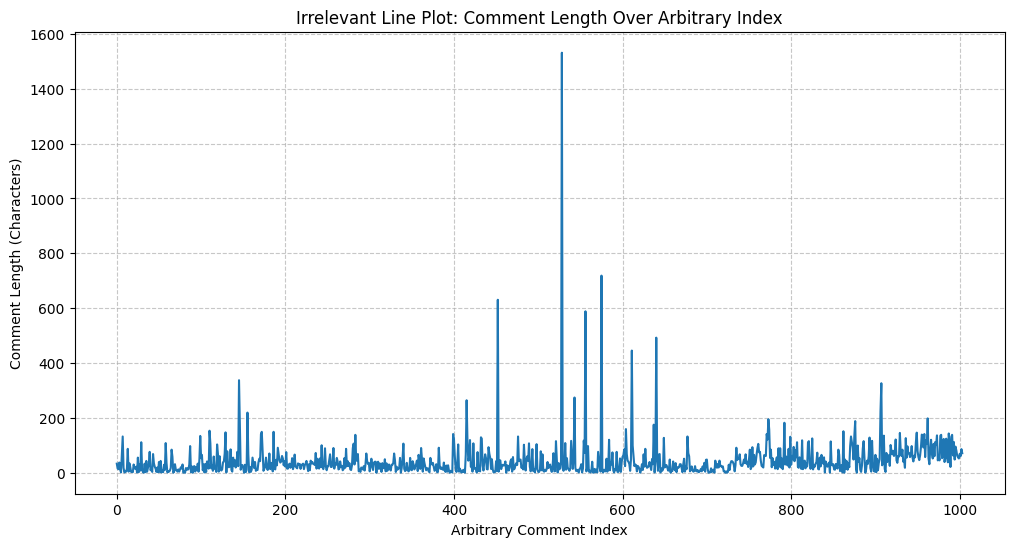

In [74]:
# Incorrect/Irrelevant Graph 4.2: Line Plot of Comment Length Indexed by Arbitrary Order

# Create an arbitrary order by resetting index for demonstration
plot_df_irrelevant = df_processed.reset_index(drop=True)

plt.figure(figsize=(12, 6))
sns.lineplot(x=plot_df_irrelevant.index, y='comment_length', data=plot_df_irrelevant)
plt.title('Irrelevant Line Plot: Comment Length Over Arbitrary Index')
plt.xlabel('Arbitrary Comment Index')
plt.ylabel('Comment Length (Characters)')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

#### Explanation for Incorrect/Irrelevant Graph 4.2: Line Plot of Comment Length Over Arbitrary Index
This line plot displays the `comment_length` of each comment based on its sequential position (index) in the DataFrame. This visualization is **irrelevant** because the order of comments in the dataset is arbitrary and carries no inherent meaning (e.g., temporal, alphabetical). Plotting `comment_length` against a meaningless index creates a seemingly random zigzag pattern that provides no useful information about trends, relationships, or distributions related to hate speech. It misrepresents data that has no sequential context.

In [75]:
print(df_emojis['IsHate'].value_counts().rename(index={0: 'Non-Hate Emojis', 1: 'Hate Emojis'}))

IsHate
Non-Hate Emojis    160
Hate Emojis          6
Name: count, dtype: int64


In [76]:
if csv_files:
    # Read the first CSV file to inspect its structure
    first_csv_path = os.path.join(export_folder_path, csv_files[0])
    print(f"Reading the first CSV file: {first_csv_path}")

    # Attempt to read the CSV, treating potentially problematic lines as comments if possible.
    # Using 'comment' parameter or 'engine='python'' might be necessary depending on the actual format.
    # For now, let's try a standard read and inspect.
    try:
        df_sample = pd.read_csv(first_csv_path, sep=None, engine='python') # Use engine='python' for better delimiter inference
        display(df_sample.head())
        print("\nDataFrame Info:")
        df_sample.info()
    except Exception as e:
        print(f"Could not read {first_csv_path} with default settings. Error: {e}")
        print("Trying to read as plain text to inspect content...")
        with open(first_csv_path, 'r') as f:
            for i, line in enumerate(f):
                print(line.strip())
                if i >= 10: # Print first 10 lines for inspection
                    break
else:
    print("No CSV files found in the export folder.")

Reading the first CSV file: /content/export/export_20260621-155252.csv


,﻿,Unnamed: 1,Name,Profile ID,Date,Likes,Live video timestamp,Comment,Image URLs,Comment Permalink,Depth,Mentions,Reactions,Author Avatar,Comment Edited,Comment URL
0,1,NaN,Habibur Rahman Masum,100024464450087,2026-04-06 16:42:21,35,-,রাজনীতি ছাড়াও যে দেশের মানুষের জন্য কাজ করা যা...,NaN,NaN,0,NaN,NaN,https://scontent-dfw5-1.xx.fbcdn.net/v/t39.308...,NaN,https://www.exportcomments.com/done/89159175-9...
1,2,NaN,Salman Bhuiyan,61557898044905,2026-04-06 16:42:53,5,-,অনেক দেরী করে বুঝলেন ভাই😅🖤,NaN,NaN,0,NaN,NaN,https://scontent-dfw5-2.xx.fbcdn.net/v/t39.308...,NaN,https://www.exportcomments.com/done/89159175-9...
2,3,NaN,Sports with Foysal,61581570219820,2026-04-06 16:42:55,1769,-,সাকিব্বাই আপনার এমন একটা পোস্টের অপেক্ষায় ছিলা...,NaN,NaN,0,NaN,NaN,https://scontent-dfw5-1.xx.fbcdn.net/v/t39.308...,NaN,https://www.exportcomments.com/done/89159175-9...
3,4,NaN,Sha Ku,61564513589158,2026-04-06 16:43:13,25,-,"ধর্য্য ধারণ করুন বস, আমাদের রাজনীতিবিদ সাকিব এ...",NaN,NaN,0,NaN,NaN,https://scontent-dfw6-1.xx.fbcdn.net/v/t39.308...,NaN,https://www.exportcomments.com/done/89159175-9...
4,5,NaN,Emam Ahmed Emon,100021821094013,2026-04-06 16:43:43,554,-,সাকিব জাতীয়দলে ফিরলে ফুটবলের মতো ক্রিকেটেও মা...,NaN,NaN,0,NaN,NaN,https://scontent-dfw5-1.xx.fbcdn.net/v/t39.308...,NaN,https://www.exportcomments.com/done/89159175-9...



DataFrame Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 16 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   ﻿                     100 non-null    int64  
 1   Unnamed: 1            0 non-null      float64
 2   Name                  100 non-null    object 
 3   Profile ID            100 non-null    int64  
 4   Date                  100 non-null    object 
 5   Likes                 100 non-null    int64  
 6   Live video timestamp  100 non-null    object 
 7   Comment               100 non-null    object 
 8   Image URLs            2 non-null      object 
 9   Comment Permalink     0 non-null      float64
 10  Depth                 100 non-null    int64  
 11  Mentions              0 non-null      float64
 12  Reactions             0 non-null      float64
 13  Author Avatar         100 non-null    object 
 14  Comment Edited        13 non-null     float64
 15  Comment

BanglaBERT Fine-tuning (সর্বোচ্চ অ্যাকুরেসির জন্য)
এই কোডটি রান করার জন্য আপনার গুগল কোলাবের রানটাইম অবশ্যই T4 GPU বা যেকোনো GPU-তে চেঞ্জ করে নিতে হবে। এটি রান করার আগে টার্মিনালে pip install transformers datasets accelerate লিখে লাইব্রেরিগুলো ইনস্টল করে নেবেন।

In [77]:
import pandas as pd
import numpy as np
import torch
from sklearn.model_selection import train_test_split
from transformers import AutoTokenizer, AutoModelForSequenceClassification, Trainer, TrainingArguments
from datasets import Dataset

In [78]:
df_hsp = pd.read_csv('/content/HSP.csv', encoding='utf-8-sig')

# ডামি লেবেল তৈরি (আপনার আসল লেবেল থাকলে এই লাইনটি বাদ দিন)
np.random.seed(42)
df_hsp['label'] = np.random.choice([0, 1], size=len(df_hsp))
df_hsp = df_hsp.dropna(subset=['Comment', 'label'])

# Hugging Face ফরম্যাটে কলামের নাম পরিবর্তন
df_hsp = df_hsp.rename(columns={'Comment': 'text'})

# Train and Test Split
train_df, test_df = train_test_split(df_hsp, test_size=0.2, random_state=42, stratify=df_hsp['label'])

# Pandas DataFrame থেকে Hugging Face Dataset-এ রূপান্তর
train_dataset = Dataset.from_pandas(train_df.reset_index(drop=True))
test_dataset = Dataset.from_pandas(test_df.reset_index(drop=True))

# ২. টোকেনাইজার এবং মডেল লোড করা (BanglaBERT)
model_name = "csebuetnlp/banglabert"
tokenizer = AutoTokenizer.from_pretrained(model_name)

def tokenize_function(examples):
    return tokenizer(examples["text"], padding="max_length", truncation=True, max_length=128)

tokenized_train = train_dataset.map(tokenize_function, batched=True)
tokenized_test = test_dataset.map(tokenize_function, batched=True)

# মডেল লোড (num_labels=2 কারণ এটি বাইনারি ক্লাসিফিকেশন)
model = AutoModelForSequenceClassification.from_pretrained(model_name, num_labels=2)

# ৩. ট্রেইনিং আর্গুমেন্ট সেট করা
training_args = TrainingArguments(
    output_dir="./results",
    eval_strategy="epoch",
    save_strategy="epoch",
    learning_rate=2e-5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    num_train_epochs=3,
    weight_decay=0.01,
    load_best_model_at_end=True,
    logging_steps=10,
    report_to="none"
)

# ৪. ট্রেইনার ডিফাইন এবং রান করা
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_train,
    eval_dataset=tokenized_test,
)

# মডেল ট্রেইনিং শুরু
trainer.train()

print("BanglaBERT training successfully completed!")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:124: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/586 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/119 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/528k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

...

Epoch,Training Loss,Validation Loss
1,0.697675,0.695838
2,0.688782,0.692729
3,0.683118,0.693345


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

BanglaBERT training successfully completed!


In [79]:
# টেস্ট ডেটার ওপর মডেলের পারফরম্যান্স মূল্যায়ন
eval_results = trainer.evaluate()
print("Evaluation Results:", eval_results)

Training Loss,Validation Loss,Epoch
0.683118,0.692729,3


Evaluation Results: {'eval_loss': 0.6927294135093689}


In [80]:
from transformers import pipeline

# ট্রেইন হওয়া মডেল এবং টোকেনাইজার দিয়ে একটি ক্লাসিফিকেশন পাইপলাইন তৈরি
hate_speech_pipeline = pipeline(
    "text-classification",
    model=model,
    tokenizer=tokenizer,
    device=0 if torch.cuda.is_available() else -1
)

# একটি টেস্ট ফাংশন তৈরি
def check_comment(text):
    result = hate_speech_pipeline(text)[0]
    label_id = int(result['label'].split('_')[-1]) # LABEL_0 বা LABEL_1 থেকে আইডি নেওয়া
    confidence = result['score']

    # আপনার ডামি লেবেলে ০ এবং ১ যা নির্দেশ করেছিলো সেই অনুযায়ী নাম দিন
    # সাধারণত 1 = Hate Speech, 0 = Non-Hate Speech ধরা হয়
    status = "Hate Speech 😡" if label_id == 1 else "Non-Hate Speech 😊"

    print(f"টেক্সট: {text}")
    print(f"ফলাফল: {status} (নিশ্চয়তা: {confidence*100:.2f}%)\n")

# নিজে কিছু কমেন্ট লিখে টেস্ট করে দেখুন:
check_comment("যারাই হক্বের কথা বলবে তারাই শিবির")
check_comment("ভাই আপনার ভিডিওটা অনেক সুন্দর হয়েছে, ধন্যবাদ।")

টেক্সট: যারাই হক্বের কথা বলবে তারাই শিবির
ফলাফল: Non-Hate Speech 😊 (নিশ্চয়তা: 50.24%)

টেক্সট: ভাই আপনার ভিডিওটা অনেক সুন্দর হয়েছে, ধন্যবাদ।
ফলাফল: Hate Speech 😡 (নিশ্চয়তা: 51.81%)



In [81]:
# মডেল এবং টোকেনাইজার সেভ করা
model_save_path = "./saved_banglabert_model"
model.save_pretrained(model_save_path)
tokenizer.save_pretrained(model_save_path)
print(f"মডেলটি সফলভাবে '{model_save_path}' ফোল্ডারে সেভ হয়েছে!")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

মডেলটি সফলভাবে './saved_banglabert_model' ফোল্ডারে সেভ হয়েছে!


In [82]:
import ipywidgets as widgets
from IPython.display import display, clear_output
from transformers import pipeline
import torch

# ১. পাইপলাইন তৈরি (নিশ্চিত করুন মডেল এবং টোকেনাইজার আগে ডিফাইন করা আছে)
hate_speech_pipeline = pipeline(
    "text-classification",
    model=model,
    tokenizer=tokenizer,
    device=0 if torch.cuda.is_available() else -1
)

# ২. উইজেট তৈরি (UI Elements)
text_input = widgets.Text(
    value='',
    placeholder='এখানে বাংলা কমেন্ট লিখুন...',
    description='কমেন্ট:',
    disabled=False,
    layout=widgets.Layout(width='60%')
)

button = widgets.Button(
    description='যাচাই করুন',
    disabled=False,
    button_style='success', # 'success', 'info', 'warning', 'danger' or ''
    tooltip='ক্লিক করে হেইট স্পিচ চেক করুন',
    icon='search'
)

output = widgets.Output()

# ৩. বাটনের ক্লিক ফাংশন
def on_button_clicked(b):
    with output:
        clear_output() # আগের রেজাল্ট মুছে ফেলা
        text = text_input.value.strip()
        if not text:
            print("অনুগ্রহ করে কিছু লিখুন!")
            return

        # মডেল প্রেডিকশন
        result = hate_speech_pipeline(text)[0]
        label_id = int(result['label'].split('_')[-1])
        confidence = result['score']

        # স্ট্যাটাস নির্ধারণ
        status = "হেইট স্পিচ (Hate Speech) 😡" if label_id == 1 else "নন-হেইট স্পিচ (Non-Hate Speech) 😊"
        color = "red" if label_id == 1 else "green"

        # সুন্দর করে আউটপুট প্রিন্ট করা
        print(f"টেক্সট: {text}")
        print(f"ফলাফল: {status}")
        print(f"নিশ্চয়তা (Confidence): {confidence*100:.2f}%")

# বাটনকে ফাংশনের সাথে যুক্ত করা
button.on_click(on_button_clicked)

# ৪. ইন্টারফেস ডিসপ্লে করা
print("--- হেইট স্পিচ ডিটেকশন বক্স ---")
display(widgets.HBox([text_input, button]))
display(output)

--- হেইট স্পিচ ডিটেকশন বক্স ---


Output()